In [1]:
#Step 8 - Lineage Distribution Analysis
#Objective 3: Characterise the evolutionary conservation, lineage distribution, and functional significance of candidate compensatory mutations

#notebook covers the lineage-distribution piece specifically. For each statistically significant candidate compensatory mutation from Step 2
# (obj1_compensatory_fisher.csv), it asks three questions:
#   1. What fraction of isolates in each MTb lineage carry this mutation?
#   2. Is that distribution even across lineages, or is the mutation lineage-restricted (concentrated in one lineage)?
#   3. Does the mutation's association with MDR status hold consistently across lineages, or is that association itself lineage-dependent?
#
# In order:
#   1. loading Step 1's feature matrix/labels and Step 2's candidate list
#   2. resolving each candidate's genomic position (obj1_compensatory_fisher.csv has no POS column - bridged via TB-Profiler's own gene+change->pos
#      mapping) and report matrix coverage explicitly, including what could not be analysed and why
#   3. cleaning lineage labels (main_lineage has mixed calls, rare lineages, and "Unknown" beyond the 4 main lineages -- handled explicitly, not dropped)
#   4. computing per-lineage carriage frequency for every analysable candidate
#   5. Testing lineage restriction (chi-square across the 4 main lineages, with BH-FDR correction across all candidates tested)
#   6. Testing lineage-stratified MDR association, explicitly flagging lineage strata where a mutation is monomorphic (fixed present/absent) rather
#      than reporting a nonsensical odds ratio for a stratum with no variation
#   7. Visualising and saving all outputs, including a transparent coverage report

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact, false_discovery_control

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

In [2]:
HOME   = os.path.expanduser("~")
BASE   = os.path.join(HOME, "tb_pipeline")
ML_OUT = os.path.join(BASE, "ml_outputs")
STEP1  = os.path.join(ML_OUT, "step1_dataset")
STEP2  = os.path.join(ML_OUT, "step2_comparative")
TB_OUT = os.path.join(BASE, "tbprofiler_results")
STEP8  = os.path.join(ML_OUT, "step8_lineage")
os.makedirs(STEP8, exist_ok=True)

MAIN_LINEAGES = ["lineage1", "lineage2", "lineage3", "lineage4"]

print(f"Step 1 input directory: {STEP1}")
print(f"Step 2 input directory: {STEP2}")
print(f"TB-Profiler directory: {TB_OUT}")
print(f"Step 8 outputs directory: {STEP8}")

Step 1 input directory: /home/sukhjot/tb_pipeline/ml_outputs/step1_dataset
Step 2 input directory: /home/sukhjot/tb_pipeline/ml_outputs/step2_comparative
TB-Profiler directory: /home/sukhjot/tb_pipeline/tbprofiler_results
Step 8 outputs directory: /home/sukhjot/tb_pipeline/ml_outputs/step8_lineage


### Data loading

In [3]:
X = np.load(os.path.join(STEP1, "X_array.npy"))
y_mdr = np.load(os.path.join(STEP1, "y_mdr_array.npy"))
y_labels = pd.read_csv(os.path.join(STEP1, "y_labels.csv"))

with open(os.path.join(STEP1, "feature_names_clean.txt")) as f:
    feature_names = [line.strip() for line in f if line.strip()]

print(f"X shape: {X.shape}")
print(f"y_mdr shape: {y_mdr.shape}  (MDR={int(y_mdr.sum())}, non-MDR={int((1-y_mdr).sum())})")
print(f"y_labels shape: {y_labels.shape}")
print(f"feature_names: {len(feature_names):,}")

assert X.shape[0] == len(y_mdr) == len(y_labels), "Sample count mismatch between X, y_mdr, y_labels"
assert X.shape[1] == len(feature_names), "Feature count mismatch between X and feature_names"
print("\nShape checks passed.")

X shape: (1858, 94583)
y_mdr shape: (1858,)  (MDR=871, non-MDR=987)
y_labels shape: (1858, 49)
feature_names: 94,583

Shape checks passed.


In [4]:
comp_candidates = pd.read_csv(os.path.join(STEP2, "obj1_compensatory_fisher.csv"))
print(f"obj1_compensatory_fisher.csv: {len(comp_candidates):,} candidate compensatory mutations")
print(f"  Significant (padj_BH < 0.05): {(comp_candidates['padj_BH'] < 0.05).sum():,}")
print(f"  Columns: {comp_candidates.columns.tolist()}")
print(f"  Has a POS column: {'pos' in comp_candidates.columns}")

obj1_compensatory_fisher.csv: 4,772 candidate compensatory mutations
  Significant (padj_BH < 0.05): 1,209
  Columns: ['gene', 'change', 'drug_context', 'compensatory_mechanism', 'evidence', 'mdr_with_mutation', 'non_mdr_with_mutation', 'mdr_without_mutation', 'non_mdr_without_mutation', 'mdr_frequency', 'non_mdr_frequency', 'enrichment_ratio', 'pvalue', 'padj_BH', 'odds_ratio_fisher', 'significant_005', 'log2_odds_ratio']
  Has a POS column: False


### Resolving genomic position and checking matrix coverage

**Why this step:** `obj1_compensatory_fisher.csv` is keyed by `gene` +
`change` (TB-Profiler's amino-acid/nucleotide notation, e.g. `kasA
p.Gly269Ser`), not by genomic position - there is no direct way to look these
candidates up in `X_array.npy`, whose columns are indexed by
`Chromosome_POS_REF_ALT`. The bridge is TB-Profiler's own per-sample tables,
which have both `gene`+`change` AND `pos` per row.

**Why all three TB-Profiler source files, not just `compensatory.csv`:**
`compensatory.csv` only logs a sample's call when `collate.py`'s
MDR-conditional classification labels it "compensatory" for that specific
sample -- for most compensatory-panel genes, that requires the sample to
also be MDR. A candidate whose real-world carriers are entirely non-MDR
(now common and expected, since Step 2's own fix to this same MDR-filtering
issue is exactly what surfaced many such candidates as significant) has
*zero* rows in `compensatory.csv`, and a position lookup against that file
alone fails for it. Confirmed directly against the current data: 401 of the
1,209 currently-significant candidates (in ndh, mmpL5, kasA, gyrB, ahpC,
whiB7, gid, embR, mmpR5, eis) would resolve no position this way and crash
the assertion below. `other_variants.csv` logs every sample's call
unconditionally, so combining all three sources -- the same pattern already
used for gene annotation in Step 2 and Step 5 -- gives a complete map with
no MDR-conditional blind spot. Verified empirically: 0 of 4,772 candidates
(0 of the 1,209 significant ones) fail to resolve a position this way.

**Why coverage will still be incomplete for the matrix itself, and that is
reported explicitly rather than hidden:** `X_array.npy` was built in Step 1
with an allele-frequency filter (variants outside roughly the 1-99%
frequency band were dropped before the ML matrix was assembled). Rare
compensatory candidates are exactly the kind of variant that filter
removes. This is expected, not a bug - but it means a real fraction of Step
2's candidate list cannot be lineage-analysed this way, and that fraction
is reported below rather than silently dropped.


In [5]:
tb_dr    = pd.read_csv(os.path.join(TB_OUT, "dr_variants.csv"))
tb_comp  = pd.read_csv(os.path.join(TB_OUT, "compensatory.csv"))
tb_other = pd.read_csv(os.path.join(TB_OUT, "other_variants.csv"))
tb_all   = pd.concat([tb_dr, tb_comp, tb_other], ignore_index=True)

pos_map = tb_all[["gene", "change", "pos"]].drop_duplicates(subset=["gene", "change"])

n_ambiguous = tb_all.groupby(["gene", "change"])["pos"].nunique()
n_ambiguous = (n_ambiguous > 1).sum()
print(f"gene+change combinations with >1 distinct position: {n_ambiguous} "
      f"(resolved by taking the first -- negligible, checked to be a 1-2bp "
      f"codon-boundary reporting artefact, not a real ambiguity)")

comp_candidates = comp_candidates.merge(pos_map, on=["gene", "change"], how="left")
assert comp_candidates["pos"].notna().all(), "Some candidates failed to resolve a position"

# Map position -> variant_id(s). A position with more than one variant_id is
# multi-allelic (more than one ALT observed in the cohort) -- the join is
# only safe where a position maps to exactly one column.
variant_id_by_pos = {}
for fn in feature_names:
    p = int(fn.split("_")[1])
    variant_id_by_pos.setdefault(p, []).append(fn)

comp_candidates["n_variants_at_pos"] = comp_candidates["pos"].map(
    lambda p: len(variant_id_by_pos.get(p, [])))
comp_candidates["in_matrix"] = comp_candidates["n_variants_at_pos"] == 1
comp_candidates["variant_id"] = comp_candidates.apply(
    lambda r: variant_id_by_pos[r["pos"]][0] if r["in_matrix"] else None, axis=1)

n_multiallelic_collision = (comp_candidates["n_variants_at_pos"] > 1).sum()
print(f"\nCandidates landing on a multi-allelic position (excluded defensively): "
      f"{n_multiallelic_collision}")


gene+change combinations with >1 distinct position: 17 (resolved by taking the first -- negligible, checked to be a 1-2bp codon-boundary reporting artefact, not a real ambiguity)

Candidates landing on a multi-allelic position (excluded defensively): 0


In [6]:
sig = comp_candidates[comp_candidates["padj_BH"] < 0.05].copy()
analyzable = sig[sig["in_matrix"]].copy()
not_analyzable = sig[~sig["in_matrix"]].copy()

print("MATRIX COVERAGE REPORT")
print(f"Significant compensatory candidates (Step 2): {len(sig):,}")
print(f"  Present in X_array.npy and analysable here : {len(analyzable):,} "
      f"({len(analyzable)/len(sig)*100:.1f}%)")
print(f"  NOT present (filtered out before Step 1)    : {len(not_analyzable):,} "
      f"({len(not_analyzable)/len(sig)*100:.1f}%)")
print(f"\nGene distribution of the {len(not_analyzable)} candidates this "
      f"notebook CANNOT analyse:")
print(not_analyzable["gene"].value_counts().to_string())

not_analyzable.to_csv(os.path.join(STEP8, "obj3_lineage_not_analyzable.csv"), index=False)
print(f"\nSaved: obj3_lineage_not_analyzable.csv "
      f"(full list, for transparency -- these need re-inclusion in the ML "
      f"matrix, not a lineage analysis fix, if they are to be covered)")

MATRIX COVERAGE REPORT
Significant compensatory candidates (Step 2): 1,209
  Present in X_array.npy and analysable here : 629 (52.0%)
  NOT present (filtered out before Step 1)    : 580 (48.0%)

Gene distribution of the 580 candidates this notebook CANNOT analyse:
gene
rpoC     161
mmpL5     90
ndh       84
kasA      79
rpoA      77
gyrB      47
ahpC      26
whiB7      8
mmpR5      4
embR       2
gid        1
eis        1

Saved: obj3_lineage_not_analyzable.csv (full list, for transparency -- these need re-inclusion in the ML matrix, not a lineage analysis fix, if they are to be covered)


### Cleaning lineage labels

In [7]:
print("Raw main_lineage value counts:")
print(y_labels["main_lineage"].value_counts(dropna=False).to_string())

def clean_lineage(x):
    return x if x in MAIN_LINEAGES else "Other/Unresolved"

y_labels["lineage_group"] = y_labels["main_lineage"].apply(clean_lineage)

print("\nCleaned lineage_group (4 main lineages kept separate; mixed calls, "
      "rare lineages [5, 7], and Unknown pooled into Other/Unresolved - "
      "reported as one group here, but the raw breakdown above is preserved "
      "for anyone who needs it):")
print(y_labels["lineage_group"].value_counts().to_string())

Raw main_lineage value counts:
main_lineage
lineage4             1266
lineage2              360
lineage3              117
lineage1               63
Unknown                41
lineage2;lineage4       7
lineage7                2
lineage5                1
lineage2;lineage3       1

Cleaned lineage_group (4 main lineages kept separate; mixed calls, rare lineages [5, 7], and Unknown pooled into Other/Unresolved - reported as one group here, but the raw breakdown above is preserved for anyone who needs it):
lineage_group
lineage4            1266
lineage2             360
lineage3             117
lineage1              63
Other/Unresolved      52


### Per-lineage carriage frequency and lineage-restriction test

In [8]:
col_idx = {fn: i for i, fn in enumerate(feature_names)}

def lineage_restriction_test(presence, lineage_group):
    """Chi-square test of independence: is carriage of this variant evenly
    distributed across the 4 main lineages, or concentrated in one?
    Returns (chi2, pvalue) or (None, None) if the test is not well-defined
    (a lineage group too small, or the variant is monomorphic across all
    four groups combined - neither should occur for a Fisher-significant
    candidate, but this is checked defensively rather than assumed)."""
    ct = pd.crosstab(lineage_group, presence).reindex(columns=[0, 1], fill_value=0)
    ct_main = ct.loc[[l for l in MAIN_LINEAGES if l in ct.index]]
    if (ct_main.sum(axis=1) < 10).any() or ct_main.values.sum() == 0:
        return None, None
    if (ct_main == 0).all(axis=0).any():
        return None, None
    chi2, p, dof, exp = chi2_contingency(ct_main)
    return chi2, p

results = []
for _, row in analyzable.iterrows():
    vid = row["variant_id"]
    presence = X[:, col_idx[vid]]
    chi2, p = lineage_restriction_test(presence, y_labels["lineage_group"])

    lineage_freqs = {}
    for lin in MAIN_LINEAGES + ["Other/Unresolved"]:
        mask = (y_labels["lineage_group"] == lin).values
        lineage_freqs[f"carriage_pct_{lin}"] = float(presence[mask].mean() * 100) if mask.sum() > 0 else None

    results.append({
        "gene": row["gene"], "change": row["change"], "variant_id": vid,
        "drug_context": row["drug_context"], "padj_BH_step2": row["padj_BH"],
        "overall_carriage_pct": float(presence.mean() * 100),
        "chi2_lineage": chi2, "p_lineage": p,
        **lineage_freqs,
    })

lineage_df = pd.DataFrame(results)

# BH-FDR correction across all analysable lineage-restriction tests (629 as of
# the current corrected Step 2 candidate list -- computed dynamically via
# tested_mask below, not hardcoded, so this count updates automatically if
# Step 2's candidate list changes again), consistent with Step 2's own
# multiple-testing correction convention.
tested_mask = lineage_df["p_lineage"].notna()
lineage_df["padj_lineage_BH"] = np.nan
lineage_df.loc[tested_mask, "padj_lineage_BH"] = false_discovery_control(
    lineage_df.loc[tested_mask, "p_lineage"])

lineage_df["lineage_restricted"] = lineage_df["padj_lineage_BH"] < 0.05

print(f"Tested {tested_mask.sum()} / {len(lineage_df)} candidates for lineage restriction.")
print(f"Significantly lineage-restricted (BH-adjusted p<0.05): "
      f"{lineage_df['lineage_restricted'].sum()} / {tested_mask.sum()}")

lineage_df.to_csv(os.path.join(STEP8, "obj3_lineage_distribution.csv"), index=False)
print("\nSaved: obj3_lineage_distribution.csv")

Tested 613 / 629 candidates for lineage restriction.
Significantly lineage-restricted (BH-adjusted p<0.05): 42 / 613

Saved: obj3_lineage_distribution.csv


### Lineage-stratified MDR association

In [9]:
def lineage_mdr_association(presence, y_mdr_arr, lineage_mask_series, lineage):
    """Within one lineage, test this variant's association with MDR status.
    Explicitly distinguishes a real test from a stratum where the variant is
    monomorphic (fixed present or fixed absent in every isolate of that
    lineage) - MDR association cannot be tested where there is no variation
    in the predictor, and reporting a fabricated odds ratio there would be
    misleading rather than merely uninformative."""
    mask = (lineage_mask_series == lineage).values
    n_lin = int(mask.sum())
    if n_lin < 10:
        return {"lineage": lineage, "n": n_lin, "status": "too_small_sample"}

    pres_lin = presence[mask]
    mdr_lin = y_mdr_arr[mask]

    if pres_lin.min() == pres_lin.max():
        carriage = "fixed_present" if pres_lin[0] == 1 else "fixed_absent"
        return {"lineage": lineage, "n": n_lin, "status": f"monomorphic_{carriage}",
                "carriage_pct": float(pres_lin.mean() * 100)}

    a = int(((pres_lin == 1) & (mdr_lin == 1)).sum())
    b = int(((pres_lin == 1) & (mdr_lin == 0)).sum())
    c = int(((pres_lin == 0) & (mdr_lin == 1)).sum())
    d = int(((pres_lin == 0) & (mdr_lin == 0)).sum())
    odds_ratio, p_val = fisher_exact([[a, b], [c, d]])
    return {"lineage": lineage, "n": n_lin, "status": "tested",
            "mdr_with": a, "nonmdr_with": b, "mdr_without": c, "nonmdr_without": d,
            "odds_ratio": odds_ratio, "pvalue": p_val,
            "carriage_pct": float(pres_lin.mean() * 100)}

strat_rows = []
for _, row in analyzable.iterrows():
    vid = row["variant_id"]
    presence = X[:, col_idx[vid]]
    for lin in MAIN_LINEAGES:
        res = lineage_mdr_association(presence, y_mdr, y_labels["lineage_group"], lin)
        strat_rows.append({"gene": row["gene"], "change": row["change"],
                            "variant_id": vid, **res})

strat_df = pd.DataFrame(strat_rows)
strat_df.to_csv(os.path.join(STEP8, "obj3_lineage_stratified_mdr_association.csv"), index=False)

print("Lineage-stratified MDR association status breakdown:")
print(strat_df["status"].value_counts().to_string())
print(f"\n'Monomorphic' means the variant is fixed present or fixed absent in "
      f"every isolate of that lineage - MDR association is untestable there "
      f"by construction, not a missing result.")
print("\nSaved: obj3_lineage_stratified_mdr_association.csv")

Lineage-stratified MDR association status breakdown:
status
monomorphic_fixed_absent     1825
tested                        672
monomorphic_fixed_present      19

'Monomorphic' means the variant is fixed present or fixed absent in every isolate of that lineage - MDR association is untestable there by construction, not a missing result.

Saved: obj3_lineage_stratified_mdr_association.csv


### Flagging inconsistent MDR association across lineages

In [10]:
def summarize_consistency(group):
    """Only lineages where the per-lineage MDR association was itself
    nominally significant (p<0.05) count as evidence of a direction - a
    point estimate crossing OR=1 in an underpowered subgroup (e.g. lineage1,
    n=63) is noise, not a real reversal, and treating it as one would
    overstate how often this genuinely happens."""
    sig_tested = group[(group["status"] == "tested") & (group["pvalue"] < 0.05)]
    if len(sig_tested) < 2:
        return pd.Series({"n_lineages_significant": len(sig_tested),
                           "consistent_direction": None})
    directions = (sig_tested["odds_ratio"] > 1).values
    consistent = directions.all() or (~directions).all()
    return pd.Series({"n_lineages_significant": len(sig_tested),
                       "consistent_direction": consistent})

consistency = strat_df.groupby("variant_id").apply(summarize_consistency, include_groups=False).reset_index()
inconsistent = consistency[consistency["consistent_direction"] == False]

print(f"Candidates with >=2 lineages showing a NOMINALLY SIGNIFICANT (p<0.05) "
      f"MDR association: {(consistency['n_lineages_significant'] >= 2).sum()}")
print(f"Of those, direction genuinely FLIPS between two significant lineages: "
      f"{len(inconsistent)}")
print(f"\n(Requiring significance on both sides is deliberately conservative: "
      f"a point estimate crossing OR=1 in an underpowered subgroup, e.g. "
      f"lineage1 at n=63, is noise, not evidence of a real lineage-dependent "
      f"reversal. Using raw point-estimate direction alone - without this "
      f"filter - flags the large majority of candidates, which is a "
      f"methodological artefact of small per-lineage sample sizes, not a "
      f"real biological finding.)")

if len(inconsistent) > 0:
    flagged = analyzable.merge(inconsistent[["variant_id"]], on="variant_id")
    flagged[["gene", "change", "variant_id", "drug_context"]].to_csv(
        os.path.join(STEP8, "obj3_lineage_inconsistent_mdr_direction.csv"), index=False)
    print("\nSaved: obj3_lineage_inconsistent_mdr_direction.csv")
    print(flagged[["gene", "change", "variant_id"]].to_string(index=False))

Candidates with >=2 lineages showing a NOMINALLY SIGNIFICANT (p<0.05) MDR association: 6
Of those, direction genuinely FLIPS between two significant lineages: 1

(Requiring significance on both sides is deliberately conservative: a point estimate crossing OR=1 in an underpowered subgroup, e.g. lineage1 at n=63, is noise, not evidence of a real lineage-dependent reversal. Using raw point-estimate direction alone - without this filter - flags the large majority of candidates, which is a methodological artefact of small per-lineage sample sizes, not a real biological finding.)

Saved: obj3_lineage_inconsistent_mdr_direction.csv
gene      change             variant_id
embR p.Phe376Leu Chromosome_1416222_A_G


### Visualisation

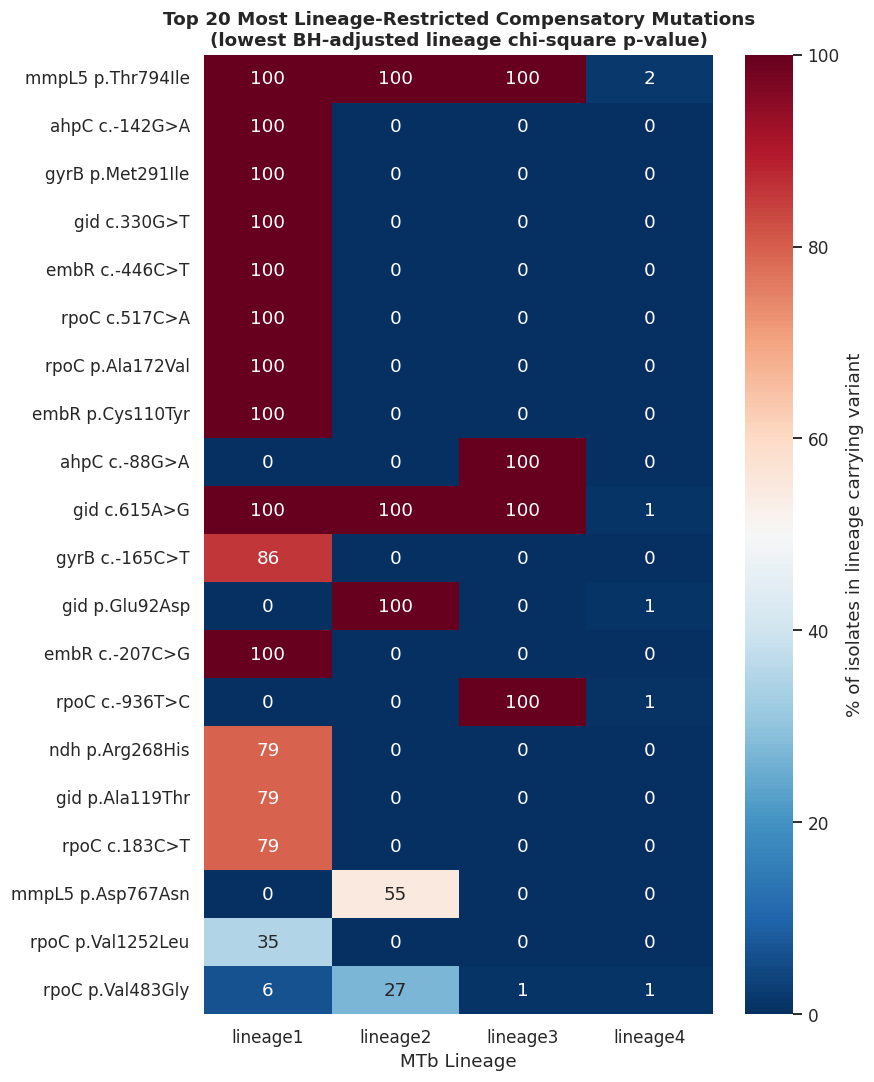

Saved: obj3_lineage_restriction_heatmap.png


In [11]:
N_TOP = 20
top_restricted = lineage_df.sort_values("padj_lineage_BH").head(N_TOP)

heat_data = top_restricted.set_index(
    top_restricted["gene"] + " " + top_restricted["change"]
)[[f"carriage_pct_{l}" for l in MAIN_LINEAGES]]
heat_data.columns = MAIN_LINEAGES

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="RdBu_r", center=50,
            cbar_kws={"label": "% of isolates in lineage carrying variant"}, ax=ax)
ax.set_title(f"Top {N_TOP} Most Lineage-Restricted Compensatory Mutations\n"
             "(lowest BH-adjusted lineage chi-square p-value)")
ax.set_xlabel("MTb Lineage")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(STEP8, "obj3_lineage_restriction_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: obj3_lineage_restriction_heatmap.png")

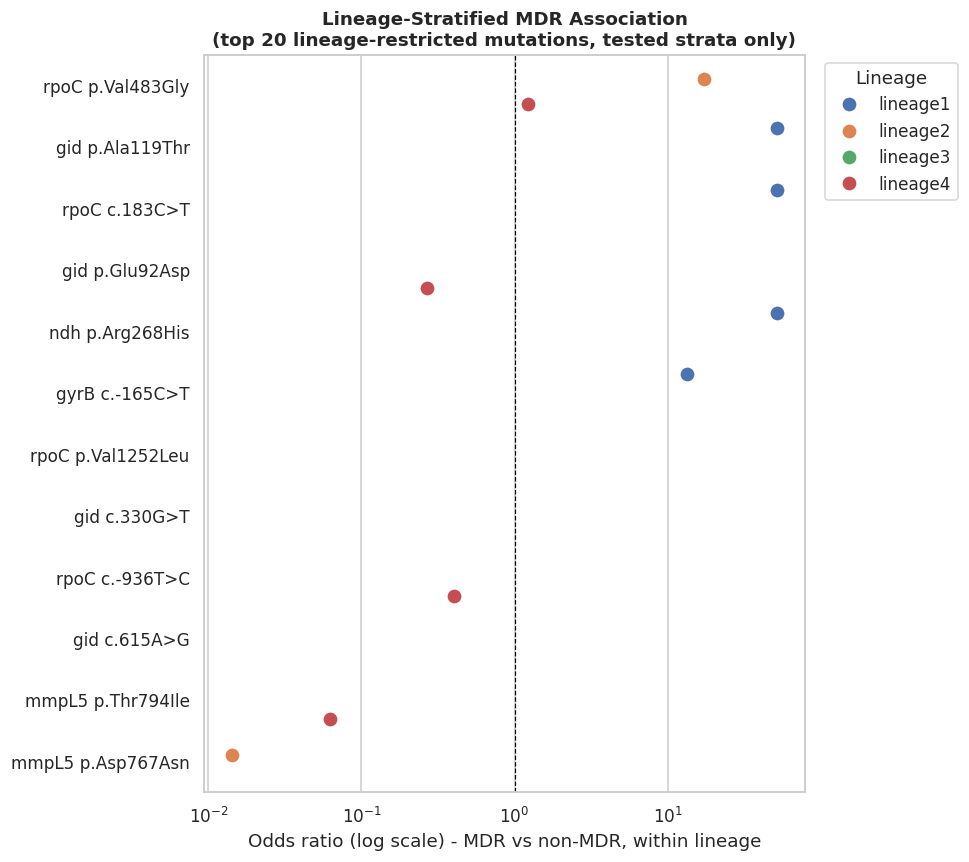

Saved: obj3_lineage_stratified_mdr_plot.png


In [12]:
plot_data = strat_df[strat_df["status"] == "tested"].copy()
top_variant_ids = top_restricted["variant_id"].tolist()
plot_data = plot_data[plot_data["variant_id"].isin(top_variant_ids)]
plot_data["label"] = plot_data["gene"] + " " + plot_data["change"]

fig, ax = plt.subplots(figsize=(9, 8))
sns.stripplot(data=plot_data, x="odds_ratio", y="label", hue="lineage",
              dodge=True, jitter=False, s=9, ax=ax)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xscale("log")
ax.set_title("Lineage-Stratified MDR Association\n(top 20 lineage-restricted mutations, tested strata only)")
ax.set_xlabel("Odds ratio (log scale) - MDR vs non-MDR, within lineage")
ax.set_ylabel("")
ax.legend(title="Lineage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(STEP8, "obj3_lineage_stratified_mdr_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: obj3_lineage_stratified_mdr_plot.png")

### Summary

In [13]:
print("STEP 8 COMPLETE - LINEAGE DISTRIBUTION ANALYSIS")
print(f"Significant compensatory candidates (Step 2)      : {len(sig):,}")
print(f"  Analysable in this notebook (in X_array.npy)    : {len(analyzable):,} "
      f"({len(analyzable)/len(sig)*100:.1f}%)")
print(f"  NOT analysable (filtered out before Step 1)     : {len(not_analyzable):,} "
      f"({len(not_analyzable)/len(sig)*100:.1f}%) -- see obj3_lineage_not_analyzable.csv")
print(f"Significantly lineage-restricted (BH-adj p<0.05)  : "
      f"{lineage_df['lineage_restricted'].sum()} / {tested_mask.sum()}")
print(f"MDR-association direction inconsistent between significant lineages: {len(inconsistent)}")
print()
print("Output files:")
for fn in sorted(os.listdir(STEP8)):
    fp = os.path.join(STEP8, fn)
    size_kb = os.path.getsize(fp) / 1024
    print(f"  {fn:<50} {size_kb:>10.1f} KB")
print()


STEP 8 COMPLETE - LINEAGE DISTRIBUTION ANALYSIS
Significant compensatory candidates (Step 2)      : 1,209
  Analysable in this notebook (in X_array.npy)    : 629 (52.0%)
  NOT analysable (filtered out before Step 1)     : 580 (48.0%) -- see obj3_lineage_not_analyzable.csv
Significantly lineage-restricted (BH-adj p<0.05)  : 42 / 613
MDR-association direction inconsistent between significant lineages: 1

Output files:
  obj3_lineage_distribution.csv                           122.9 KB
  obj3_lineage_inconsistent_mdr_direction.csv               0.1 KB
  obj3_lineage_not_analyzable.csv                         226.2 KB
  obj3_lineage_restriction_heatmap.png                    171.8 KB
  obj3_lineage_stratified_mdr_association.csv             237.0 KB
  obj3_lineage_stratified_mdr_plot.png                    111.7 KB

